# 第６回　ネットワーク分析の基礎

## 6-1 NetworkX Library

In [1]:
import networkx as nx
from networkx.algorithms import community
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

%matplotlib inline


In [2]:
# 無向グラフの作成
G = nx.Graph()

### nodeの追加

In [3]:
# グラフにnodeを追加
G.add_node(1)
print(G.nodes)

[1]


In [4]:
# ラベル付きnodeを追加
G.add_node('one')

# グラフに属性付きノード追加
G.add_node(2, weight=5)

print(G.nodes)

[1, 'one', 2]


In [5]:
# 属性には任意のオブジェクトを付加できる
G.add_node(3, name=['node', 'number', 'three'])
print(G.nodes)

# リストの要素からノード追加
# 集合, 辞書, 文字列, グラフオブジェクトも指定可能
G.add_nodes_from([4,5,6])

print(G.nodes)
# すべてをリストとして返す
print(G.nodes.data())


[1, 'one', 2, 3]
[1, 'one', 2, 3, 4, 5, 6]
[(1, {}), ('one', {}), (2, {'weight': 5}), (3, {'name': ['node', 'number', 'three']}), (4, {}), (5, {}), (6, {})]


In [6]:
# ノードの属性情報を辞書として返す
print(G.nodes[3])
print(G.nodes[3]['name'])

{'name': ['node', 'number', 'three']}
['node', 'number', 'three']


In [7]:
# ノードの繰り返し
for n in G:
  print(n)

1
one
2
3
4
5
6


### エッジの追加

In [8]:
G.add_edge(1,2)

G.add_edge(2,3, weight=10, name="edge from 2 to 3")

G.add_edges_from([(3,4), (3,5), (2,4)])

# タプルの3番目の要素をエッジの重みとして、リストから重み付きエッジ追加
G.add_weighted_edges_from([(4,5,20),(5,6,30)])

In [9]:
# グラフに含まれるすべてのエッジをリストとして返す
print(G.edges)
print(G.edges.data())

[(1, 2), (2, 3), (2, 4), (3, 4), (3, 5), (4, 5), (5, 6)]
[(1, 2, {}), (2, 3, {'weight': 10, 'name': 'edge from 2 to 3'}), (2, 4, {}), (3, 4, {}), (3, 5, {}), (4, 5, {'weight': 20}), (5, 6, {'weight': 30})]


In [10]:
for e in G.edges:
  print(e)

(1, 2)
(2, 3)
(2, 4)
(3, 4)
(3, 5)
(4, 5)
(5, 6)


### エッジとノードの隣接や属性

In [11]:
# ノード2に隣接するノード
print(list(G.neighbors(2)))

# ノード隣接する情報を辞書を返す
print(G[2])
print(G.adj[2])

[1, 3, 4]
{1: {}, 3: {'weight': 10, 'name': 'edge from 2 to 3'}, 4: {}}
{1: {}, 3: {'weight': 10, 'name': 'edge from 2 to 3'}, 4: {}}


In [12]:
# エッジの情報
print(G[2][3])

# エッジの属性
print(G[2][3]['name'])

{'weight': 10, 'name': 'edge from 2 to 3'}
edge from 2 to 3


### グラフの描写

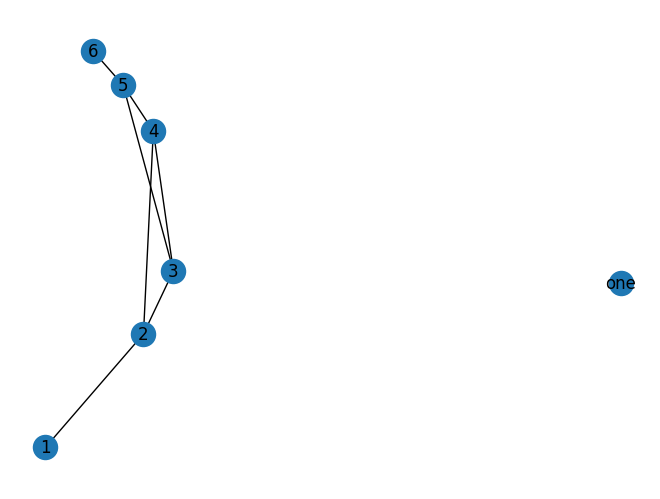

In [13]:
nx.draw(G, with_labels=True)

### ノード・エッジの削除

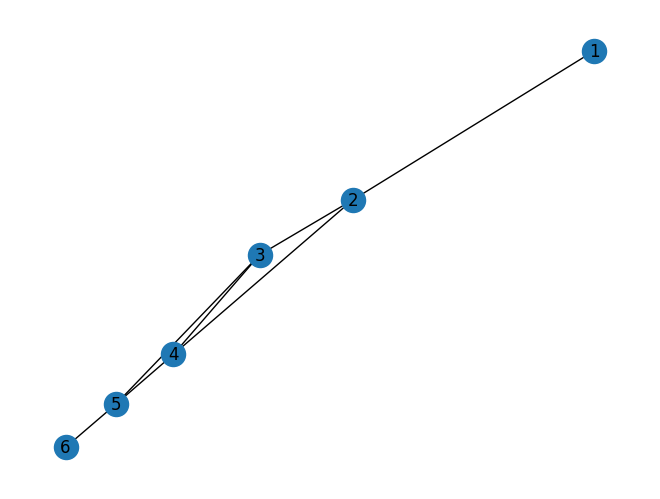

In [14]:
G.remove_node('one')
nx.draw(G, with_labels=True)

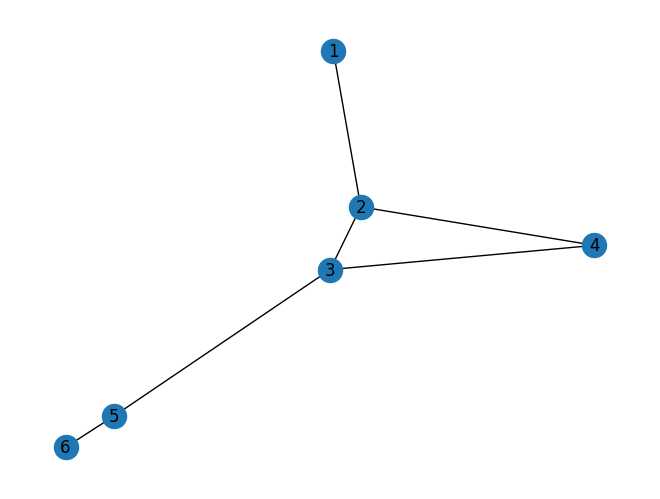

In [15]:
G.remove_edge(4,5)
nx.draw(G, with_labels=True)

In [16]:
# 全てクリア
#G.clear

# エッジの有無を確認
print(G.has_edge(1,2))
print(G.has_edge(1,3))

True
False


### 図を保存

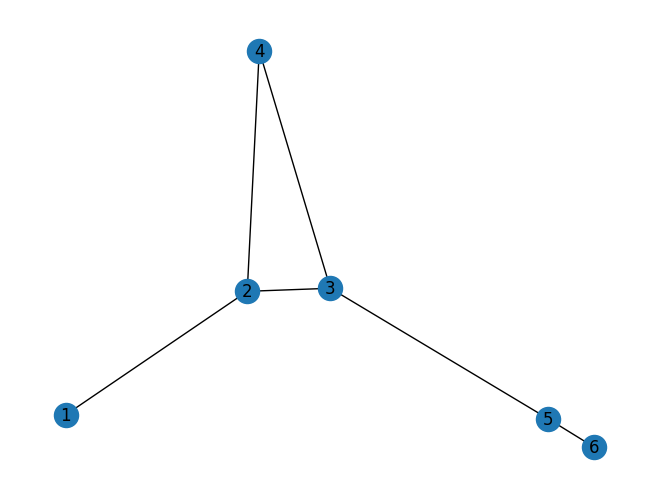

In [17]:
nx.draw(G, with_labels=True)
plt.savefig('network.png')

### ネットワークの代表値

In [18]:
# ノード数
print(len(G))

# エッジ数
print(G.size())

# エッジの重み再設定
G[2][3]['weight']=1
G[5][6]['weight']=1

6
6


## 隣接行列の扱いと最短経路の計算

In [19]:
# グラフ隣接行列
print(nx.adjacency_matrix(G))
print(nx.adjacency_matrix(G).toarray())

<Compressed Sparse Row sparse array of dtype 'int64'
	with 12 stored elements and shape (6, 6)>
  Coords	Values
  (0, 1)	1
  (1, 0)	1
  (1, 2)	1
  (1, 3)	1
  (2, 1)	1
  (2, 3)	1
  (2, 4)	1
  (3, 1)	1
  (3, 2)	1
  (4, 2)	1
  (4, 5)	1
  (5, 4)	1
[[0 1 0 0 0 0]
 [1 0 1 1 0 0]
 [0 1 0 1 1 0]
 [0 1 1 0 0 0]
 [0 0 1 0 0 1]
 [0 0 0 0 1 0]]


In [20]:
# 隣接行列の積
A=nx.adjacency_matrix(G).toarray()

print(np.dot(A,A))

[[1 0 1 1 0 0]
 [0 3 1 1 1 0]
 [1 1 3 1 0 1]
 [1 1 1 2 1 0]
 [0 1 0 1 2 0]
 [0 0 1 0 0 1]]


In [21]:
# 最短経路
path = dict(nx.shortest_path(G))
print(path[1][6])
print(path[4][6])

# ノード1からの最短経路
print(nx.shortest_path(G,1))

# ノード1と6の間の最短経路
print(nx.shortest_path(G,1,6))
# ノード1と6の間の最短経路長
print(nx.shortest_path_length(G,1,6))

[1, 2, 3, 5, 6]
[4, 3, 5, 6]
{1: [1], 2: [1, 2], 3: [1, 2, 3], 4: [1, 2, 4], 5: [1, 2, 3, 5], 6: [1, 2, 3, 5, 6]}
[1, 2, 3, 5, 6]
4


In [22]:
# 平均最短距離
print(nx.average_shortest_path_length(G))

# 平均クラスタリング係数
print(nx.average_clustering(G))

# 次数中心性 (次数/ネットワークの最大次数（n-1)で標準化)
print(nx.degree_centrality(G))
# 近接中心性
print(nx.closeness_centrality(G))
# 媒介中心性
print(nx.betweenness_centrality(G))


1.9333333333333333
0.27777777777777773
{1: 0.2, 2: 0.6000000000000001, 3: 0.6000000000000001, 4: 0.4, 5: 0.4, 6: 0.2}
{1: 0.4166666666666667, 2: 0.625, 3: 0.7142857142857143, 4: 0.5555555555555556, 5: 0.5555555555555556, 6: 0.38461538461538464}
{1: 0.0, 2: 0.4, 3: 0.6000000000000001, 4: 0.0, 5: 0.4, 6: 0.0}


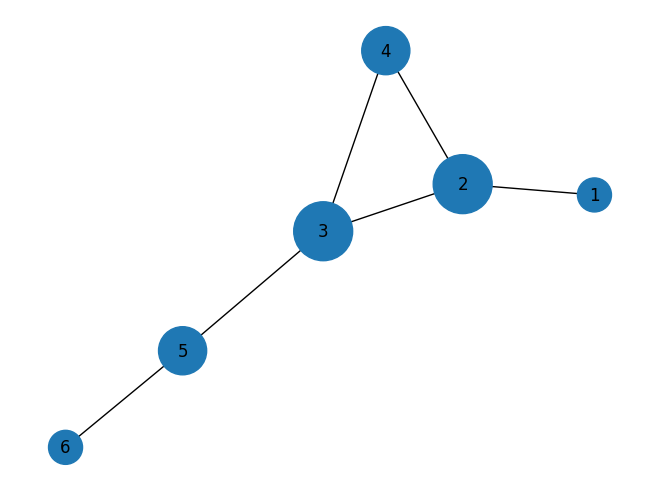

In [23]:
# 媒介中心性の値でノードの大きさを変えて可視化

# ノードと中心性の辞書形式で値だけを取り出すのが.values()
node_size = np.array(list((nx.degree_centrality(G)).values()))

nx.draw(G, with_labels=True,
        # 中心製の値そのままだと小さいから3000倍したのをnode_sizeとしている
        node_size = [v*3000 for v in node_size])

### 有向グラフの作成

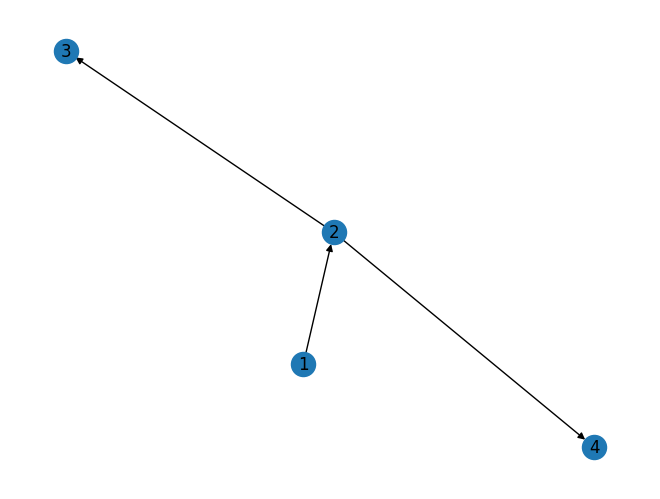

In [24]:
# 有効グラフの作成（ただし自己閉路を含まない）
DiG = nx.DiGraph()
DiG.add_edges_from([(1,2),(2,3),(2,4)])
nx.draw(DiG, with_labels=True)


In [25]:
# 有向グラフにおける点の後続点
print (list(DiG.successors(2)))
# 有向グラフにおける点の先行点
print(list(DiG.predecessors(2)))

[3, 4]
[1]


In [26]:
# ノードの次数
print(DiG.degree(2))
# ノードの入次数
print(DiG.in_degree(2))
# ノードの出次数
print(DiG.out_degree(2))
#グラフの各ノードの次数
list(DiG.degree)

3
1
2


[(1, 1), (2, 3), (3, 1), (4, 1)]